# T12B Local Woodtype Probability By Species

Local notebook for checking CNN woodtype soft-routing probabilities by species. It reads saved T12 outputs from `outputs/T12_cnn_soft_routing`, creates per-species probability grids for train OOF and test, and saves summary CSV files under `outputs/T12_cnn_soft_routing/metrics`.

In [7]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "outputs").exists():
            return candidate
    raise FileNotFoundError("Project root not found. Run this notebook inside the repository.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import DataConfig
from src.utils.plotting import configure_matplotlib_japanese

sns.set_theme(style="whitegrid")
configure_matplotlib_japanese()

config = DataConfig()
T12_DIR = PROJECT_ROOT / "outputs" / "T12_cnn_soft_routing"
OOF_DIR = T12_DIR / "oof"
TEST_DIR = T12_DIR / "test"
FIGURE_DIR = T12_DIR / "figures"
METRIC_DIR = T12_DIR / "metrics"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("T12_DIR =", T12_DIR)

PROJECT_ROOT = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D
T12_DIR = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing


In [8]:
train_path = OOF_DIR / "train_woodtype_oof_probs.csv"
test_path = TEST_DIR / "test_woodtype_probs.csv"

if not train_path.exists():
    raise FileNotFoundError(f"Run T12 first or place the OOF probability file here: {train_path}")

train_prob = pd.read_csv(train_path)
test_prob = pd.read_csv(test_path) if test_path.exists() else None

print("train:", train_prob.shape, train_path)
display(train_prob.head())

if test_prob is not None:
    print("test:", test_prob.shape, test_path)
    display(test_prob.head())
else:
    print("test probability file was not found:", test_path)

train: (1322, 9) C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\oof\train_woodtype_oof_probs.csv


,sample number,species number,樹種,true_woodtype,pred_woodtype,prob_woodtype_hardwood,prob_woodtype_softwood,maxprob_woodtype,entropy_woodtype
0,1,1,イチョウ,softwood,softwood,0.180959,0.819041,0.819041,0.472844
1,2,1,イチョウ,softwood,softwood,0.048369,0.951631,0.951631,0.193683
2,3,1,イチョウ,softwood,softwood,0.145682,0.854318,0.854318,0.415145
3,4,1,イチョウ,softwood,softwood,0.107993,0.892007,0.892007,0.342299
4,5,1,イチョウ,softwood,softwood,0.083726,0.916274,0.916274,0.287777


test: (550, 8) C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\test\test_woodtype_probs.csv


,sample number,species number,樹種,pred_woodtype,prob_woodtype_hardwood,prob_woodtype_softwood,maxprob_woodtype,entropy_woodtype
0,95,2,クスノキ,softwood,0.489000,0.511000,0.511000,0.692905
1,96,2,クスノキ,hardwood,0.552235,0.447765,0.552235,0.687680
2,97,2,クスノキ,hardwood,0.599810,0.400190,0.599810,0.673089
3,98,2,クスノキ,hardwood,0.584552,0.415448,0.584552,0.678780
4,99,2,クスノキ,hardwood,0.540388,0.459612,0.540388,0.689881


In [9]:
def pick_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def species_column(df: pd.DataFrame) -> str:
    col = pick_col(df, [config.species_name_col, "??", "species", config.species_col])
    if col is None:
        raise ValueError(f"species column was not found. columns={list(df.columns)}")
    return col


def sort_column(df: pd.DataFrame) -> str | None:
    return pick_col(df, [config.sample_col, "sample number", "row_index"])


def add_species_index(df: pd.DataFrame, species_col: str, sort_col: str | None) -> pd.DataFrame:
    out = df.copy()
    sort_keys = [species_col, sort_col] if sort_col is not None else [species_col]
    out = out.sort_values(sort_keys).reset_index(drop=True)
    out["species_index"] = out.groupby(species_col, dropna=False).cumcount()
    return out


def woodtype_prob_cols(df: pd.DataFrame) -> tuple[str, str]:
    soft_col = "prob_woodtype_softwood"
    hard_col = "prob_woodtype_hardwood"
    missing = [col for col in [soft_col, hard_col] if col not in df.columns]
    if missing:
        raise ValueError(f"missing probability columns: {missing}")
    return soft_col, hard_col


def plot_woodtype_prob_grid(df: pd.DataFrame, split_name: str, output_path: Path) -> None:
    sp_col = species_column(df)
    order_col = sort_column(df)
    soft_col, hard_col = woodtype_prob_cols(df)

    work = add_species_index(df, sp_col, order_col)
    species_values = list(work[sp_col].dropna().astype(str).unique())
    n_species = len(species_values)
    ncols = 3 if n_species > 6 else 2
    nrows = math.ceil(n_species / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.8 * ncols, 3.4 * nrows), sharey=True)
    axes = np.asarray(axes).reshape(-1)

    for ax, species in zip(axes, species_values):
        mask = work[sp_col].astype(str) == species
        g = work.loc[mask]
        ax.plot(g["species_index"], g[soft_col], marker="o", ms=3.5, lw=1.4, label="softwood")
        ax.plot(g["species_index"], g[hard_col], marker="o", ms=3.5, lw=1.4, label="hardwood")
        ax.set_title(f"{species}  n={len(g)}")
        ax.set_xlabel("index within species")
        ax.set_ylabel("probability")
        ax.set_ylim(-0.03, 1.03)
        ax.axhline(0.5, color="0.35", lw=0.8, ls="--", alpha=0.6)
        ax.grid(True, alpha=0.25)

    for ax in axes[n_species:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.suptitle(f"CNN woodtype probability by species ({split_name})", y=0.995, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(output_path, dpi=220)
    plt.show()
    print("saved:", output_path)

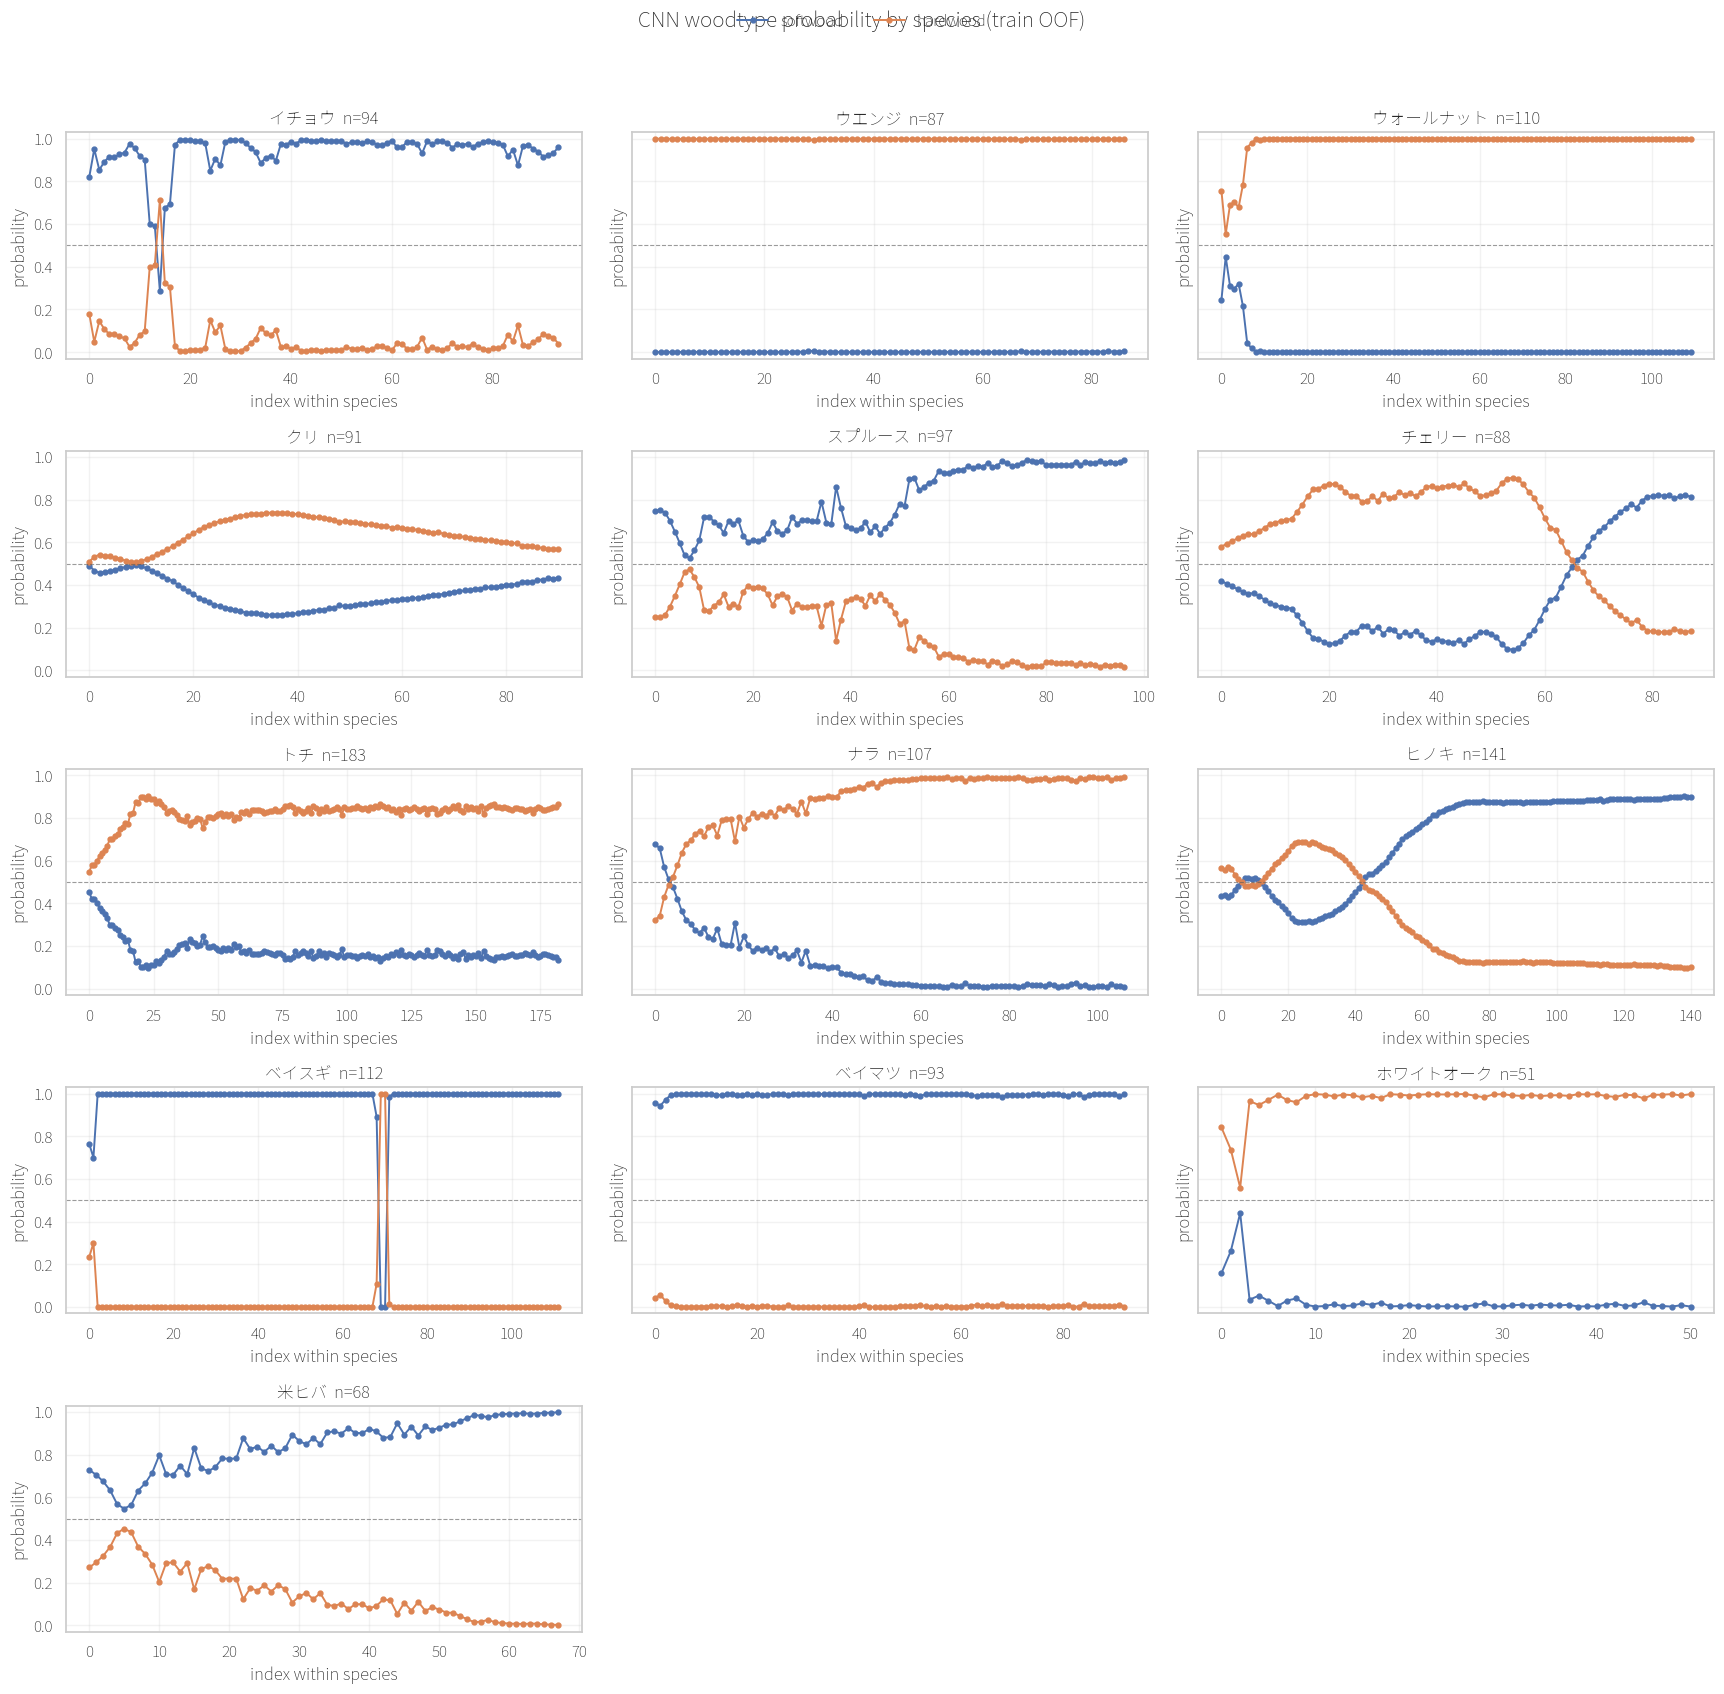

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\figures\woodtype_prob_by_species_grid_train.png


In [10]:
plot_woodtype_prob_grid(
    train_prob,
    "train OOF",
    FIGURE_DIR / "woodtype_prob_by_species_grid_train.png",
)

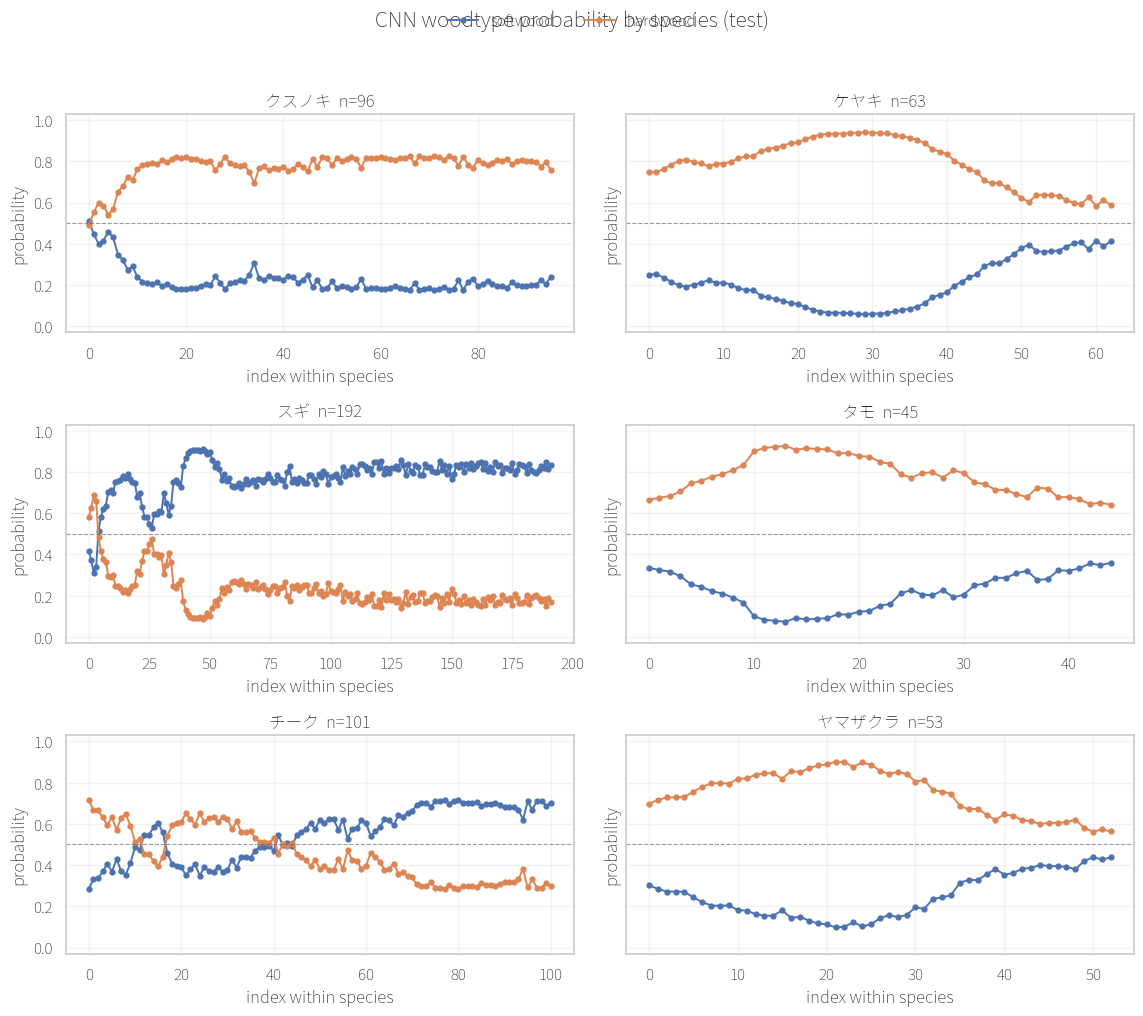

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\figures\woodtype_prob_by_species_grid_test.png


In [11]:
if test_prob is not None:
    plot_woodtype_prob_grid(
        test_prob,
        "test",
        FIGURE_DIR / "woodtype_prob_by_species_grid_test.png",
    )

In [12]:
def summarize_by_species(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    sp_col = species_column(df)
    metric_cols = [
        "prob_woodtype_softwood",
        "prob_woodtype_hardwood",
        "maxprob_woodtype",
        "entropy_woodtype",
    ]
    available = [col for col in metric_cols if col in df.columns]
    summary = df.groupby(sp_col, dropna=False)[available].agg(["count", "mean", "std", "min", "max"])
    summary.columns = ["_".join(col).strip() for col in summary.columns.to_flat_index()]
    summary = summary.reset_index().rename(columns={sp_col: "species"})
    summary.insert(0, "split", split_name)
    return summary


summaries = [summarize_by_species(train_prob, "train_oof")]
if test_prob is not None:
    summaries.append(summarize_by_species(test_prob, "test"))

woodtype_species_summary = pd.concat(summaries, ignore_index=True)
summary_path = METRIC_DIR / "woodtype_probability_by_species_local.csv"
woodtype_species_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
print("saved:", summary_path)
display(woodtype_species_summary)

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T12_cnn_soft_routing\metrics\woodtype_probability_by_species_local.csv


,split,species,prob_woodtype_softwood_count,prob_woodtype_softwood_mean,prob_woodtype_softwood_std,prob_woodtype_softwood_min,prob_woodtype_softwood_max,prob_woodtype_hardwood_count,prob_woodtype_hardwood_mean,prob_woodtype_hardwood_std,...,maxprob_woodtype_count,maxprob_woodtype_mean,maxprob_woodtype_std,maxprob_woodtype_min,maxprob_woodtype_max,entropy_woodtype_count,entropy_woodtype_mean,entropy_woodtype_std,entropy_woodtype_min,entropy_woodtype_max
0,train_oof,イチョウ,94,0.938464,0.101252,2.885823e-01,0.996231,94,0.061536,0.101252,...,94,0.942963,0.079022,0.593275,0.996231,94,0.180120,0.152409,2.479831e-02,0.675644
1,train_oof,ウエンジ,87,0.001120,0.001112,2.616707e-05,0.006911,87,0.998880,0.001112,...,87,0.998880,0.001112,0.993089,0.999974,87,0.008277,0.007081,3.023147e-04,0.041264
2,train_oof,ウォールナット,110,0.017329,0.071759,5.100667e-07,0.446430,110,0.982671,0.071759,...,110,0.982671,0.071759,0.553570,1.000000,110,0.036125,0.138681,7.867054e-06,0.687397
3,train_oof,クリ,91,0.360139,0.070792,2.602798e-01,0.492070,91,0.639861,0.070792,...,91,0.639861,0.070792,0.507930,0.739720,91,0.642739,0.039258,5.733494e-01,0.693021
4,train_oof,スプルース,97,0.805690,0.146167,5.259330e-01,0.985008,97,0.194310,0.146167,...,97,0.805690,0.146167,0.525933,0.985008,97,0.415970,0.230349,7.784706e-02,0.691802
5,train_oof,チェリー,88,0.350209,0.244819,9.716722e-02,0.821819,88,0.649791,0.244819,...,88,0.767907,0.100162,0.517393,0.902833,88,0.515007,0.104167,3.188137e-01,0.692542
6,train_oof,トチ,183,0.176612,0.055625,9.756046e-02,0.452514,183,0.823388,0.055625,...,183,0.823388,0.055625,0.547486,0.902440,183,0.457076,0.063734,3.196894e-01,0.688630
7,train_oof,ナラ,107,0.109986,0.143972,8.580089e-03,0.676566,107,0.890014,0.143972,...,107,0.897826,0.120477,0.512710,0.991420,107,0.258816,0.216545,4.936991e-02,0.692824
8,train_oof,ヒノキ,141,0.704125,0.215773,3.131106e-01,0.902314,141,0.295875,0.215773,...,141,0.760576,0.141908,0.500969,0.902314,141,0.496282,0.146117,3.199679e-01,0.693145
9,train_oof,ベイスギ,112,0.976113,0.137312,1.657031e-16,1.000000,112,0.023887,0.137312,...,112,0.993970,0.037088,0.700356,1.000000,112,0.015471,0.083104,1.842068e-07,0.610562
